In [1]:
# load needed python libraries matplotlib, numpy, and scikit-rf
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf

In [2]:
cold_ideals_2port = rf.read_all('3Kideals_2port')
frequency_object = cold_ideals_2port['ideal_port1_short'].frequency
fghz = cold_ideals_2port['ideal_port1_short'].f/1e9

In [5]:
ideal_thru_phasedelay

2-Port Network: '',  0.001-20.0 GHz, 10001 pts, z0=[50.+0.j 50.+0.j]

(7.0, 8.0)

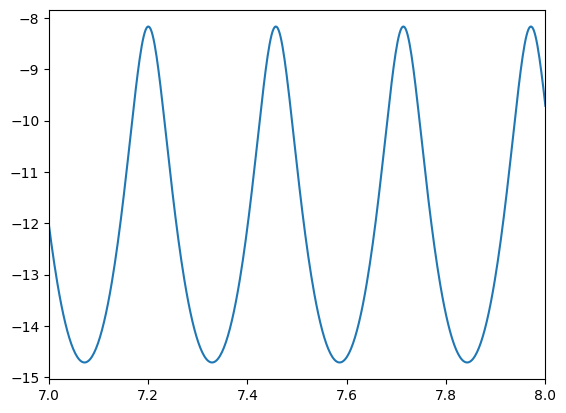

In [17]:
smatrix = []
delay  = 700 #ps
findex = 0
for element in range(len(fghz)):
    localmatrix = np.array([[0. + 0.j, np.exp(-1j*delay*fghz[findex]*np.pi/180)*1.+0.j],[ np.exp(-1j*delay*fghz[findex]*np.pi/180)*1.+0.j,0.+0.j]])
    smatrix.append(localmatrix)
    findex += 1
ideal_thru_phasedelay = rf.Network(frequency=frequency_object, s=smatrix)

smatrix = []
findex = 0
for element in range(len(fghz)):
    localmatrix = np.array([[0.6 + 0.j,0.5 + 0.j],[ 0.5+0.j,0.6+0.j]])
    smatrix.append(localmatrix)
    findex += 1
reflector = rf.Network(frequency=frequency_object, s=smatrix)
resonator = reflector**ideal_thru_phasedelay**reflector
plt.plot(fghz,resonator.s_db[:,1,0])
plt.xlim(7,8)